# BrainTumorAI v2.0 — So Sánh Model & Visualize Kết Quả

**Notebook này thực hiện 3 mục tiêu chính sau khi train xong:**

| Phần | Nội dung |
|---|---|
| **Phần 1** | Thay model và thực hiện dự đoán (Inference) |
| **Phần 2** | So sánh 2 model: EfficientNetB0 vs DenseNet121 |
| **Phần 3** | Visualize chỉ số kết quả chẩn đoán cho báo cáo |

## Phần 0 — Setup: Import & Cấu Hình

In [1]:
import os
import sys
import json
import time
import warnings
warnings.filterwarnings("ignore")

# Thêm root project vào sys.path (quan trọng khi chạy từ notebooks/)
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    accuracy_score, f1_score, precision_score, recall_score,
)
from sklearn.preprocessing import label_binarize

# Project imports
from src.config import data_cfg
from src.training.models import get_model
from src.preprocessing.transforms import get_valid_transforms

print(f"ROOT: {ROOT}")
print(f"PyTorch version : {torch.__version__}")

ROOT: D:\DS_filnal_Brain
PyTorch version : 2.13.0+cpu


In [2]:
# ── Constants ──────────────────────────────────────────────────────────────────
CLASS_NAMES = data_cfg.class_names  # ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_CONFIGS = {
    "EfficientNetB0": {
        "model_name": "efficientnet",
        "model_path": os.path.join(ROOT, "models", "efficientnet_best.pth"),
    },
    "DenseNet121": {
        "model_name": "densenet",
        "model_path": os.path.join(ROOT, "models", "densenet_best.pth"),
    },
}

REPORTS_DIR = os.path.join(ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures", "comparison")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Palette màu
PALETTE = {
    "EfficientNetB0": "#2E86AB",
    "DenseNet121":    "#E84855",
    "bg":             "#FFFFFF",
    "text":           "#222222",
    "grid":           "#E0E0E0",
}

print(f"[Setup] Device  : {DEVICE}")
print(f"[Setup] Classes : {CLASS_NAMES}")
print(f"[Setup] Figures → {FIGURES_DIR}")

[Setup] Device  : cpu
[Setup] Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']
[Setup] Figures → D:\DS_filnal_Brain\reports\figures\comparison


In [3]:
# ── Helper: Apply light style cho matplotlib axes ───────────────────────────────
def apply_dark_style(ax, title, xlabel=None, ylabel=None):
    """Áp dụng light theme chuyên nghiệp cho axes."""
    ax.set_facecolor(PALETTE["bg"])
    ax.tick_params(colors=PALETTE["text"])
    ax.title.set_color(PALETTE["text"])
    ax.spines[:].set_color(PALETTE["grid"])
    ax.grid(True, color=PALETTE["grid"], linewidth=0.5, linestyle="--")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, color=PALETTE["text"], fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=PALETTE["text"], fontsize=9)

---
## Phần 1 — Thay Model & Thực Hiện Dự Đoán (Inference)

### Hướng dẫn thay model:
- Đổi `model_name = 'efficientnet'` → dùng **EfficientNetB0**  
- Đổi `model_name = 'densenet'` → dùng **DenseNet121**  
- `model_path` phải trỏ đúng đến file `.pth` tương ứng

In [4]:
def load_model(model_name: str, model_path: str, device: torch.device) -> torch.nn.Module:
    """
    Load model từ file .pth đã được train.

    Args:
        model_name: 'efficientnet' hoặc 'densenet'
        model_path: Đường dẫn đến file .pth
        device:     CPU hoặc CUDA

    Returns:
        Model PyTorch ở trạng thái eval mode
    """
    model = get_model(model_name=model_name, num_classes=NUM_CLASSES, pretrained=False)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"  ✅ Loaded [{model_name.upper()}] từ {os.path.basename(model_path)}")
    return model


def predict_single_image(model: torch.nn.Module, image_path: str, device: torch.device) -> dict:
    """
    Dự đoán 1 ảnh MRI đơn lẻ.

    Args:
        model:      Model đã load
        image_path: Đường dẫn đến ảnh (.jpg / .png)
        device:     CPU hoặc CUDA

    Returns:
        dict: {class_name, class_idx, confidence, probabilities}
    """
    transform = get_valid_transforms()
    image     = Image.open(image_path).convert("RGB")
    tensor    = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()

    class_idx = int(np.argmax(probs))
    return {
        "class_name":    CLASS_NAMES[class_idx],
        "class_idx":     class_idx,
        "confidence":    float(probs[class_idx]),
        "probabilities": {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)},
    }

In [5]:
# ── Demo: Tìm 1 ảnh mẫu từ data/Testing và dự đoán với từng model ─────────────
def find_sample_image(test_dir: str):
    """Tìm ảnh đầu tiên trong data/Testing để demo."""
    for cls_folder in sorted(os.listdir(test_dir)):
        cls_path = os.path.join(test_dir, cls_folder)
        if os.path.isdir(cls_path):
            for f in os.listdir(cls_path):
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    return os.path.join(cls_path, f), cls_folder
    return None, None


test_dir   = os.path.join(ROOT, "data", "Testing")
sample_img, true_label = find_sample_image(test_dir)

if sample_img:
    print(f"[Demo] Ảnh mẫu  : {os.path.relpath(sample_img, ROOT)}")
    print(f"[Demo] Nhãn thật : {true_label.upper()}\n")

    for model_label, cfg in MODEL_CONFIGS.items():
        if os.path.exists(cfg["model_path"]):
            model  = load_model(cfg["model_name"], cfg["model_path"], DEVICE)
            result = predict_single_image(model, sample_img, DEVICE)
            del model  # Giải phóng RAM

            status = "✅ ĐÚNG" if result["class_name"] == true_label else "❌ SAI"
            print(f"\n  [{model_label}] Kết quả dự đoán ({status}):")
            print(f"     Dự đoán    : {result['class_name'].upper()}")
            print(f"     Độ tin cậy : {result['confidence']*100:.2f}%")
            print(f"     Xác suất từng lớp:")
            for cls, prob in result["probabilities"].items():
                bar = "█" * int(prob * 30)
                print(f"       {cls:<12} |{bar:<30}| {prob*100:.2f}%")
        else:
            print(f"  ⚠️  File model không tồn tại: {cfg['model_path']}")
else:
    print("  ⚠️  Không tìm thấy ảnh mẫu trong data/Testing/")

[Demo] Ảnh mẫu  : data\Testing\glioma\Te-gl_1.jpg
[Demo] Nhãn thật : GLIOMA

  ✅ Loaded [EFFICIENTNET] từ efficientnet_best.pth



  [EfficientNetB0] Kết quả dự đoán (✅ ĐÚNG):
     Dự đoán    : GLIOMA
     Độ tin cậy : 48.25%
     Xác suất từng lớp:
       glioma       |██████████████                | 48.25%
       meningioma   |████                          | 14.63%
       notumor      |███                           | 11.88%
       pituitary    |███████                       | 25.24%
  ✅ Loaded [DENSENET] từ densenet_best.pth



  [DenseNet121] Kết quả dự đoán (✅ ĐÚNG):
     Dự đoán    : GLIOMA
     Độ tin cậy : 55.72%
     Xác suất từng lớp:
       glioma       |████████████████              | 55.72%
       meningioma   |                              | 2.97%
       notumor      |███████████                   | 39.37%
       pituitary    |                              | 1.94%


> **💡 Cách thay model để dự đoán ảnh tùy chỉnh:**
> ```python
> # Đổi sang DenseNet121:
> model = load_model("densenet", os.path.join(ROOT, "models", "densenet_best.pth"), DEVICE)
> result = predict_single_image(model, "đường/dẫn/ảnh.jpg", DEVICE)
> print(result)
> ```

---
## Phần 2 — So Sánh 2 Model Trên Tập Test

> **Nguyên tắc vàng**: Luôn đánh giá trên **tập Test riêng biệt** chưa từng dùng trong training.  
> Dự án đã có `data/Testing/` — đây là tập Test chuẩn.

### Metrics được tính:
| Metric | Ý nghĩa |
|---|---|
| Accuracy | % dự đoán đúng tổng thể |
| **Macro F1** | Quan trọng nhất — không bị lệch bởi class imbalance |
| Precision | Trong những ca AI bảo là ung thư, bao nhiêu % đúng |
| **Recall** | Trong những ca thực sự ung thư, AI phát hiện được bao nhiêu % |
| ROC-AUC | Khả năng phân biệt từng class |

In [6]:
def build_test_loader(test_dir: str, batch_size: int = 32) -> DataLoader:
    """Tạo DataLoader cho tập Test."""
    transform = get_valid_transforms()
    dataset   = datasets.ImageFolder(test_dir, transform=transform)
    loader    = DataLoader(
        dataset, batch_size=batch_size,
        shuffle=False,
        num_workers=data_cfg.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    print(f"  [DataLoader] Thứ tự class từ ImageFolder : {dataset.classes}")
    print(f"  [DataLoader] Thứ tự class trong config   : {CLASS_NAMES}")
    if dataset.classes != CLASS_NAMES:
        print("  ⚠️  CẢNH BÁO: Thứ tự class KHÁC NHAU — Kết quả có thể sai!")
    return loader


def evaluate_model_on_testset(
    model: torch.nn.Module,
    loader: DataLoader,
    device: torch.device,
    model_label: str,
) -> dict:
    """
    Chạy inference toàn bộ tập test và tính các metrics.

    Returns:
        dict chứa toàn bộ kết quả để vẽ biểu đồ
    """
    print(f"\n  [Evaluate] Đang đánh giá [{model_label}]...")
    start = time.time()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            preds   = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)
    elapsed   = time.time() - start

    # Tính metrics
    acc        = accuracy_score(all_labels, all_preds)
    macro_f1   = f1_score(all_labels, all_preds, average="macro")
    macro_prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_rec  = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    per_cls_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

    # ROC-AUC (one-vs-rest)
    y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
    auc_per_class = {}
    fpr_tpr       = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        auc_val     = auc(fpr, tpr)
        auc_per_class[cls] = auc_val
        fpr_tpr[cls]       = (fpr, tpr)
    macro_auc = float(np.mean(list(auc_per_class.values())))

    report_str = classification_report(
        all_labels, all_preds,
        target_names=CLASS_NAMES, digits=4,
    )

    print(f"     Accuracy  : {acc*100:.2f}%")
    print(f"     Macro F1  : {macro_f1:.4f}")
    print(f"     Macro AUC : {macro_auc:.4f}")
    print(f"     Thời gian : {elapsed:.1f}s | {len(all_labels)} ảnh")
    print(f"\n  Classification Report:\n{report_str}")

    return {
        "model_label":   model_label,
        "accuracy":      acc,
        "macro_f1":      macro_f1,
        "macro_prec":    macro_prec,
        "macro_rec":     macro_rec,
        "macro_auc":     macro_auc,
        "auc_per_class": auc_per_class,
        "fpr_tpr":       fpr_tpr,
        "per_class_f1":  per_cls_f1,
        "y_true":        all_labels,
        "y_pred":        all_preds,
        "y_prob":        all_probs,
        "report_str":    report_str,
        "elapsed_s":     elapsed,
        "n_samples":     len(all_labels),
    }

In [7]:
# ── Chạy đánh giá cả 2 model ──────────────────────────────────────────────────
results     = {}
test_loader = build_test_loader(test_dir)

for model_label, cfg in MODEL_CONFIGS.items():
    if os.path.exists(cfg["model_path"]):
        model = load_model(cfg["model_name"], cfg["model_path"], DEVICE)
        results[model_label] = evaluate_model_on_testset(
            model, test_loader, DEVICE, model_label
        )
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    else:
        print(f"\n  ⚠️  [{model_label}]: model file không tồn tại.")

  [DataLoader] Thứ tự class từ ImageFolder : ['glioma', 'meningioma', 'notumor', 'pituitary']
  [DataLoader] Thứ tự class trong config   : ['glioma', 'meningioma', 'notumor', 'pituitary']
  ✅ Loaded [EFFICIENTNET] từ efficientnet_best.pth

  [Evaluate] Đang đánh giá [EfficientNetB0]...


     Accuracy  : 95.56%
     Macro F1  : 0.9548
     Macro AUC : 0.9874
     Thời gian : 56.9s | 1600 ảnh

  Classification Report:
              precision    recall  f1-score   support

      glioma     1.0000    0.8375    0.9116       400
  meningioma     0.8955    0.9850    0.9381       400
     notumor     0.9547    1.0000    0.9768       400
   pituitary     0.9852    1.0000    0.9926       400

    accuracy                         0.9556      1600
   macro avg     0.9588    0.9556    0.9548      1600
weighted avg     0.9588    0.9556    0.9548      1600



  ✅ Loaded [DENSENET] từ densenet_best.pth

  [Evaluate] Đang đánh giá [DenseNet121]...


     Accuracy  : 94.88%
     Macro F1  : 0.9478
     Macro AUC : 0.9919
     Thời gian : 2627.2s | 1600 ảnh

  Classification Report:
              precision    recall  f1-score   support

      glioma     0.9941    0.8375    0.9091       400
  meningioma     0.9127    0.9675    0.9393       400
     notumor     0.9302    1.0000    0.9639       400
   pituitary     0.9682    0.9900    0.9790       400

    accuracy                         0.9487      1600
   macro avg     0.9513    0.9487    0.9478      1600
weighted avg     0.9513    0.9487    0.9478      1600



In [8]:
# ── Bảng so sánh tóm tắt ──────────────────────────────────────────────────────
if results:
    print("=" * 65)
    print("  BẢNG SO SÁNH TÓM TẮT")
    print("=" * 65)
    header = f"{'Metric':<20} " + " | ".join(f"{k:>16}" for k in results.keys())
    print(header)
    print("-" * len(header))
    for metric, label in [
        ("accuracy",   "Accuracy"),
        ("macro_f1",   "Macro F1"),
        ("macro_prec", "Macro Precision"),
        ("macro_rec",  "Macro Recall"),
        ("macro_auc",  "Macro AUC"),
    ]:
        row = f"{label:<20} "
        row += " | ".join(f"{v[metric]:>16.4f}" for v in results.values())
        print(row)
    print("=" * 65)

  BẢNG SO SÁNH TÓM TẮT
Metric                 EfficientNetB0 |      DenseNet121
--------------------------------------------------------
Accuracy                       0.9556 |           0.9487
Macro F1                       0.9548 |           0.9478
Macro Precision                0.9588 |           0.9513
Macro Recall                   0.9556 |           0.9487
Macro AUC                      0.9874 |           0.9919


## Phần 3 — Visualize Chỉ Số Cho Báo Cáo

Tất cả biểu đồ được lưu vào `reports/figures/comparison/` với light theme chuyên nghiệp.

### 3.1 — Training History (EfficientNetB0)

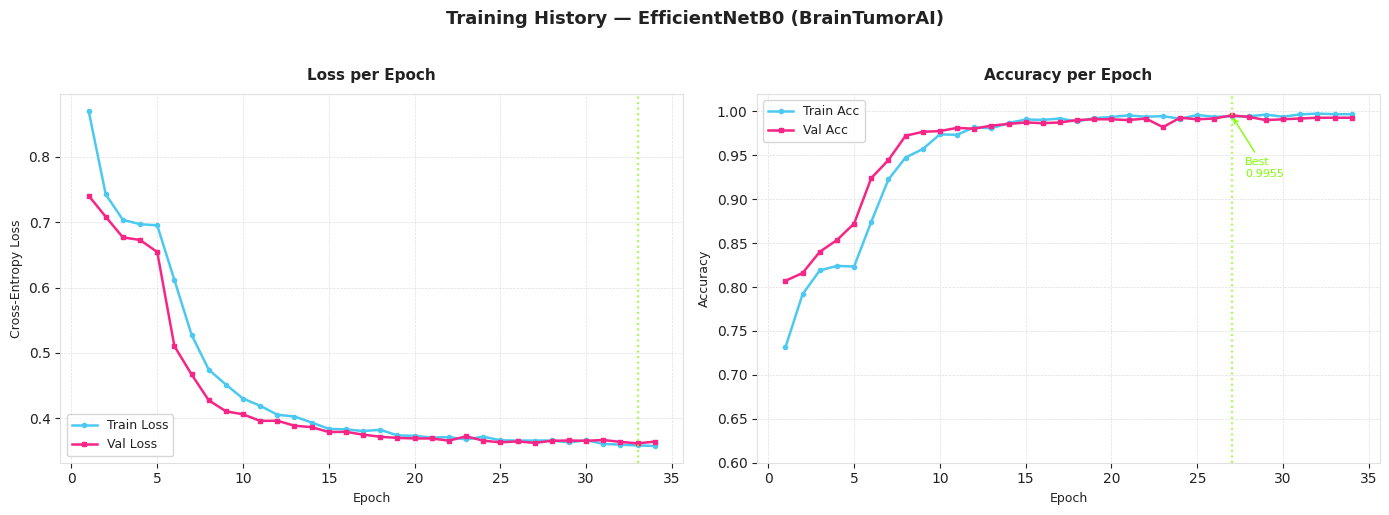

✅ Đã lưu → reports\figures\comparison\training_history_styled.png


In [9]:
history_path = os.path.join(REPORTS_DIR, "training_history.json")

if os.path.exists(history_path):
    with open(history_path, "r") as f:
        history = json.load(f)

    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(PALETTE["bg"])
    fig.suptitle(
        "Training History — EfficientNetB0 (BrainTumorAI)",
        color=PALETTE["text"], fontsize=13, fontweight="bold", y=1.02,
    )

    # Loss curve
    axes[0].plot(epochs, history["train_loss"], color="#4CC9F0",
                 marker="o", markersize=3, linewidth=1.8, label="Train Loss")
    axes[0].plot(epochs, history["val_loss"],   color="#F72585",
                 marker="s", markersize=3, linewidth=1.8, label="Val Loss")
    best_loss_ep = int(np.argmin(history["val_loss"])) + 1
    axes[0].axvline(best_loss_ep, color="#7FFF00", linestyle=":", alpha=0.7, linewidth=1.5)
    axes[0].legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["text"], fontsize=9)
    apply_dark_style(axes[0], "Loss per Epoch", "Epoch", "Cross-Entropy Loss")

    # Accuracy curve
    best_acc_ep  = int(np.argmax(history["val_acc"])) + 1
    best_acc_val = max(history["val_acc"])
    axes[1].plot(epochs, history["train_acc"], color="#4CC9F0",
                 marker="o", markersize=3, linewidth=1.8, label="Train Acc")
    axes[1].plot(epochs, history["val_acc"],   color="#F72585",
                 marker="s", markersize=3, linewidth=1.8, label="Val Acc")
    axes[1].axvline(best_acc_ep, color="#7FFF00", linestyle=":", alpha=0.7, linewidth=1.5)
    axes[1].annotate(
        f"Best\n{best_acc_val:.4f}",
        xy=(best_acc_ep, best_acc_val),
        xytext=(best_acc_ep + 0.8, best_acc_val - 0.07),
        color="#7FFF00", fontsize=8,
        arrowprops=dict(arrowstyle="->", color="#7FFF00", lw=1),
    )
    axes[1].set_ylim(0.6, 1.02)
    axes[1].legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["text"], fontsize=9)
    apply_dark_style(axes[1], "Accuracy per Epoch", "Epoch", "Accuracy")

    plt.tight_layout()
    out = os.path.join(FIGURES_DIR, "training_history_styled.png")
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print(f"✅ Đã lưu → {os.path.relpath(out, ROOT)}")
else:
    print("⚠️  Không tìm thấy training_history.json")

### 3.2 — Confusion Matrices (So Sánh 2 Model)

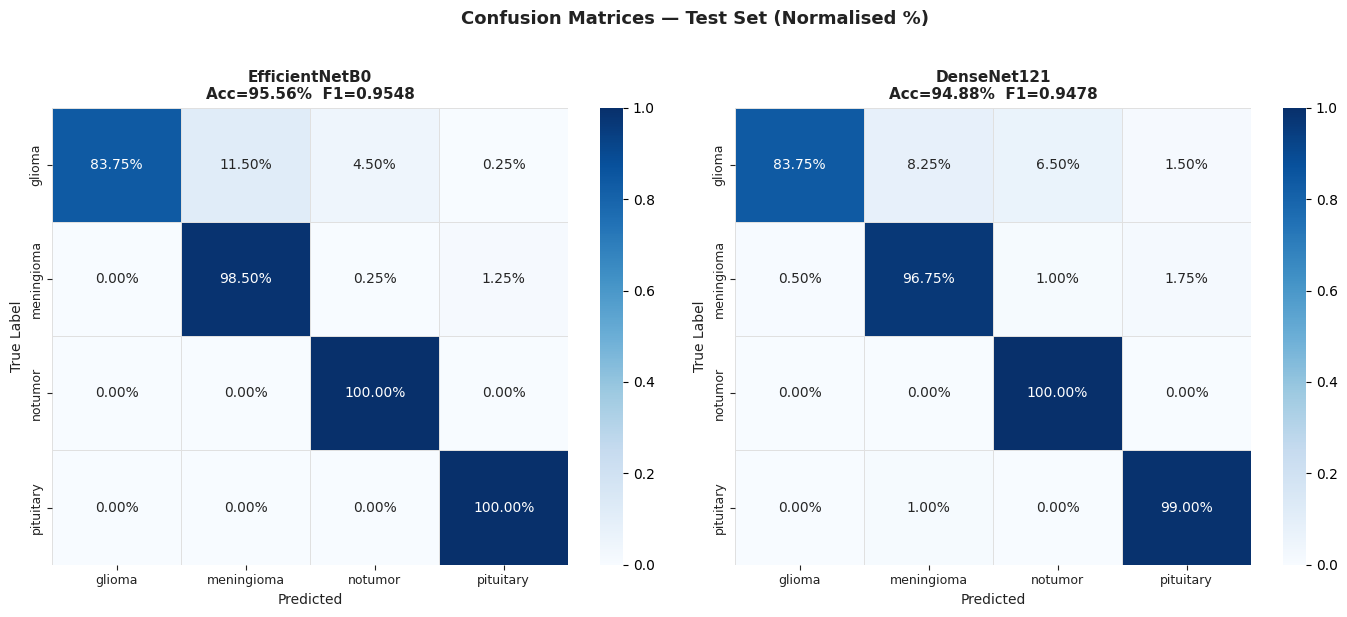

✅ Đã lưu → reports\figures\comparison\confusion_matrices_comparison.png


In [10]:
if results:
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
    fig.patch.set_facecolor(PALETTE["bg"])
    if n_models == 1:
        axes = [axes]

    for ax, (model_label, res) in zip(axes, results.items()):
        cm      = confusion_matrix(res["y_true"], res["y_pred"])
        cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        sns.heatmap(
            cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5, linecolor=PALETTE["grid"],
            annot_kws={"size": 10},
        )
        ax.set_facecolor(PALETTE["bg"])
        ax.tick_params(colors=PALETTE["text"], labelsize=9)
        ax.set_title(
            f"{model_label}\nAcc={res['accuracy']*100:.2f}%  F1={res['macro_f1']:.4f}",
            color=PALETTE["text"], fontsize=11, fontweight="bold",
        )
        ax.set_xlabel("Predicted", color=PALETTE["text"])
        ax.set_ylabel("True Label", color=PALETTE["text"])

    fig.suptitle(
        "Confusion Matrices — Test Set (Normalised %)",
        color=PALETTE["text"], fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    out = os.path.join(FIGURES_DIR, "confusion_matrices_comparison.png")
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print(f"✅ Đã lưu → {os.path.relpath(out, ROOT)}")

### 3.3 — ROC-AUC Curves (Mỗi Class)

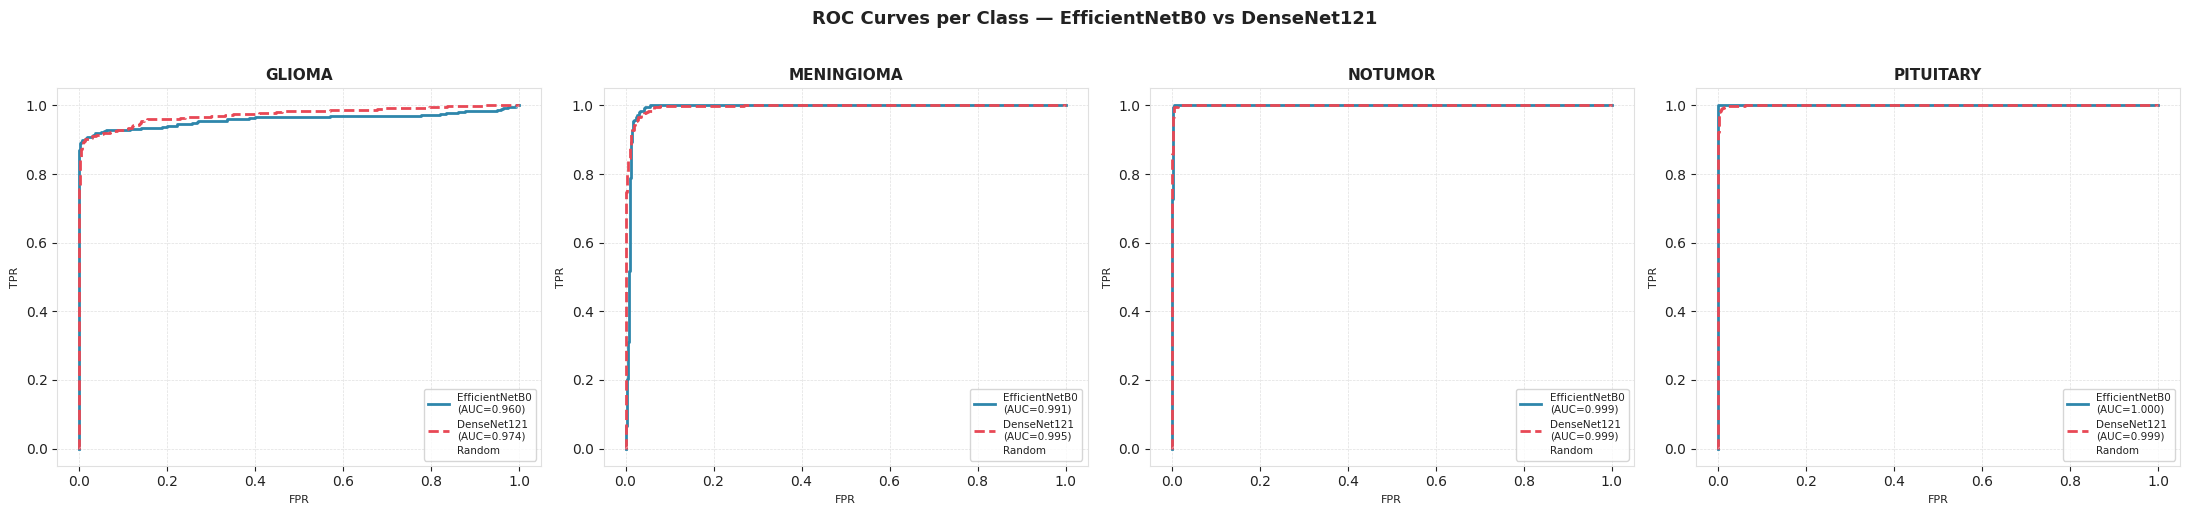

✅ Đã lưu → reports\figures\comparison\roc_curves_comparison.png


In [11]:
if results:
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5.5 * NUM_CLASSES, 5))
    fig.patch.set_facecolor(PALETTE["bg"])
    fig.suptitle(
        "ROC Curves per Class — EfficientNetB0 vs DenseNet121",
        color=PALETTE["text"], fontsize=13, fontweight="bold", y=1.02,
    )

    for col, cls in enumerate(CLASS_NAMES):
        ax = axes[col]
        ax.set_facecolor(PALETTE["bg"])
        ax.tick_params(colors=PALETTE["text"])
        ax.spines[:].set_color(PALETTE["grid"])
        ax.grid(True, color=PALETTE["grid"], linewidth=0.5, linestyle="--")

        for model_label, res in results.items():
            fpr, tpr = res["fpr_tpr"][cls]
            auc_val  = res["auc_per_class"][cls]
            ls = "-" if model_label == "EfficientNetB0" else "--"
            ax.plot(fpr, tpr, linestyle=ls, color=PALETTE[model_label],
                    linewidth=2.0, label=f"{model_label}\n(AUC={auc_val:.3f})")

        ax.plot([0, 1], [0, 1], "w--", lw=0.8, alpha=0.4, label="Random")
        ax.set_title(cls.upper(), color=PALETTE["text"], fontsize=11, fontweight="bold")
        ax.set_xlabel("FPR", color=PALETTE["text"], fontsize=8)
        ax.set_ylabel("TPR", color=PALETTE["text"], fontsize=8)
        ax.legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["text"], fontsize=7.5)

    plt.tight_layout()
    out = os.path.join(FIGURES_DIR, "roc_curves_comparison.png")
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print(f"✅ Đã lưu → {os.path.relpath(out, ROOT)}")

### 3.4 — Metrics Comparison Bar Chart

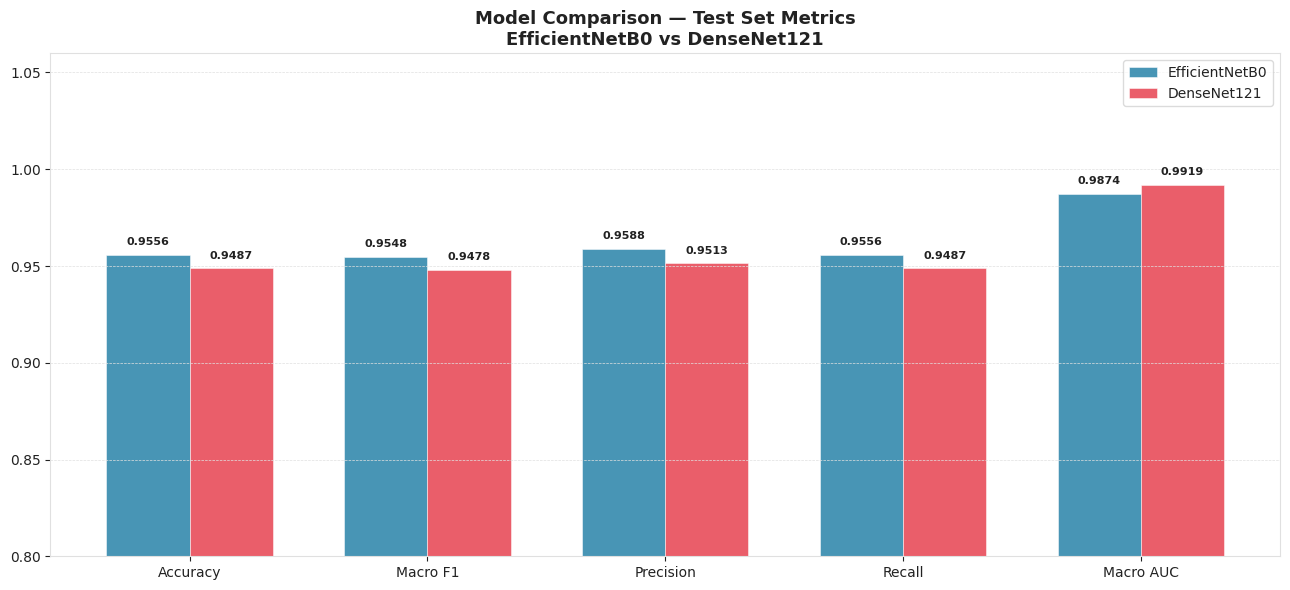

✅ Đã lưu → reports\figures\comparison\metrics_comparison_bar.png


In [12]:
if results:
    metrics_map = [
        ("accuracy",   "Accuracy"),
        ("macro_f1",   "Macro F1"),
        ("macro_prec", "Precision"),
        ("macro_rec",  "Recall"),
        ("macro_auc",  "Macro AUC"),
    ]
    metric_keys   = [m[0] for m in metrics_map]
    metric_labels = [m[1] for m in metrics_map]
    x     = np.arange(len(metric_keys))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor(PALETTE["bg"])
    ax.set_facecolor(PALETTE["bg"])

    for i, (model_label, res) in enumerate(results.items()):
        vals   = [res[k] for k in metric_keys]
        offset = (i - 0.5) * width
        bars   = ax.bar(
            x + offset, vals, width,
            color=PALETTE[model_label], alpha=0.88,
            label=model_label, edgecolor="white", linewidth=0.4,
        )
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f"{val:.4f}",
                ha="center", va="bottom",
                color=PALETTE["text"], fontsize=8, fontweight="bold",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, color=PALETTE["text"], fontsize=10)
    ax.tick_params(colors=PALETTE["text"])
    ax.set_ylim(0.8, 1.06)
    ax.spines[:].set_color(PALETTE["grid"])
    ax.grid(True, axis="y", color=PALETTE["grid"], linewidth=0.5, linestyle="--")
    ax.set_title(
        "Model Comparison — Test Set Metrics\nEfficientNetB0 vs DenseNet121",
        color=PALETTE["text"], fontsize=13, fontweight="bold",
    )
    ax.legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["text"],
              fontsize=10, framealpha=0.7)

    plt.tight_layout()
    out = os.path.join(FIGURES_DIR, "metrics_comparison_bar.png")
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print(f"✅ Đã lưu → {os.path.relpath(out, ROOT)}")

### 3.5 — Per-Class F1 Score Comparison

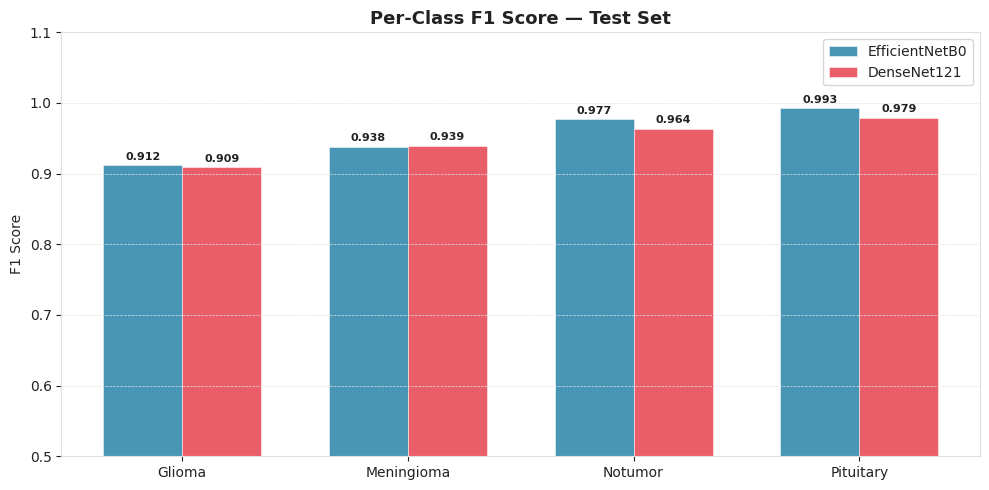

✅ Đã lưu → reports\figures\comparison\per_class_f1_comparison.png


In [13]:
if results:
    x     = np.arange(NUM_CLASSES)
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor(PALETTE["bg"])
    ax.set_facecolor(PALETTE["bg"])

    for i, (model_label, res) in enumerate(results.items()):
        offset = (i - 0.5) * width
        bars   = ax.bar(
            x + offset, res["per_class_f1"], width,
            color=PALETTE[model_label], alpha=0.88,
            label=model_label, edgecolor="white", linewidth=0.4,
        )
        for bar, val in zip(bars, res["per_class_f1"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}",
                ha="center", va="bottom",
                color=PALETTE["text"], fontsize=8, fontweight="bold",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in CLASS_NAMES],
                       color=PALETTE["text"], fontsize=10)
    ax.tick_params(colors=PALETTE["text"])
    ax.set_ylim(0.5, 1.1)
    ax.spines[:].set_color(PALETTE["grid"])
    ax.grid(True, axis="y", color=PALETTE["grid"], linewidth=0.5, linestyle="--")
    ax.set_title(
        "Per-Class F1 Score — Test Set",
        color=PALETTE["text"], fontsize=13, fontweight="bold",
    )
    ax.set_ylabel("F1 Score", color=PALETTE["text"])
    ax.legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["text"], fontsize=10)

    plt.tight_layout()
    out = os.path.join(FIGURES_DIR, "per_class_f1_comparison.png")
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print(f"✅ Đã lưu → {os.path.relpath(out, ROOT)}")

### 3.6 — Dashboard Báo Cáo Tổng Hợp

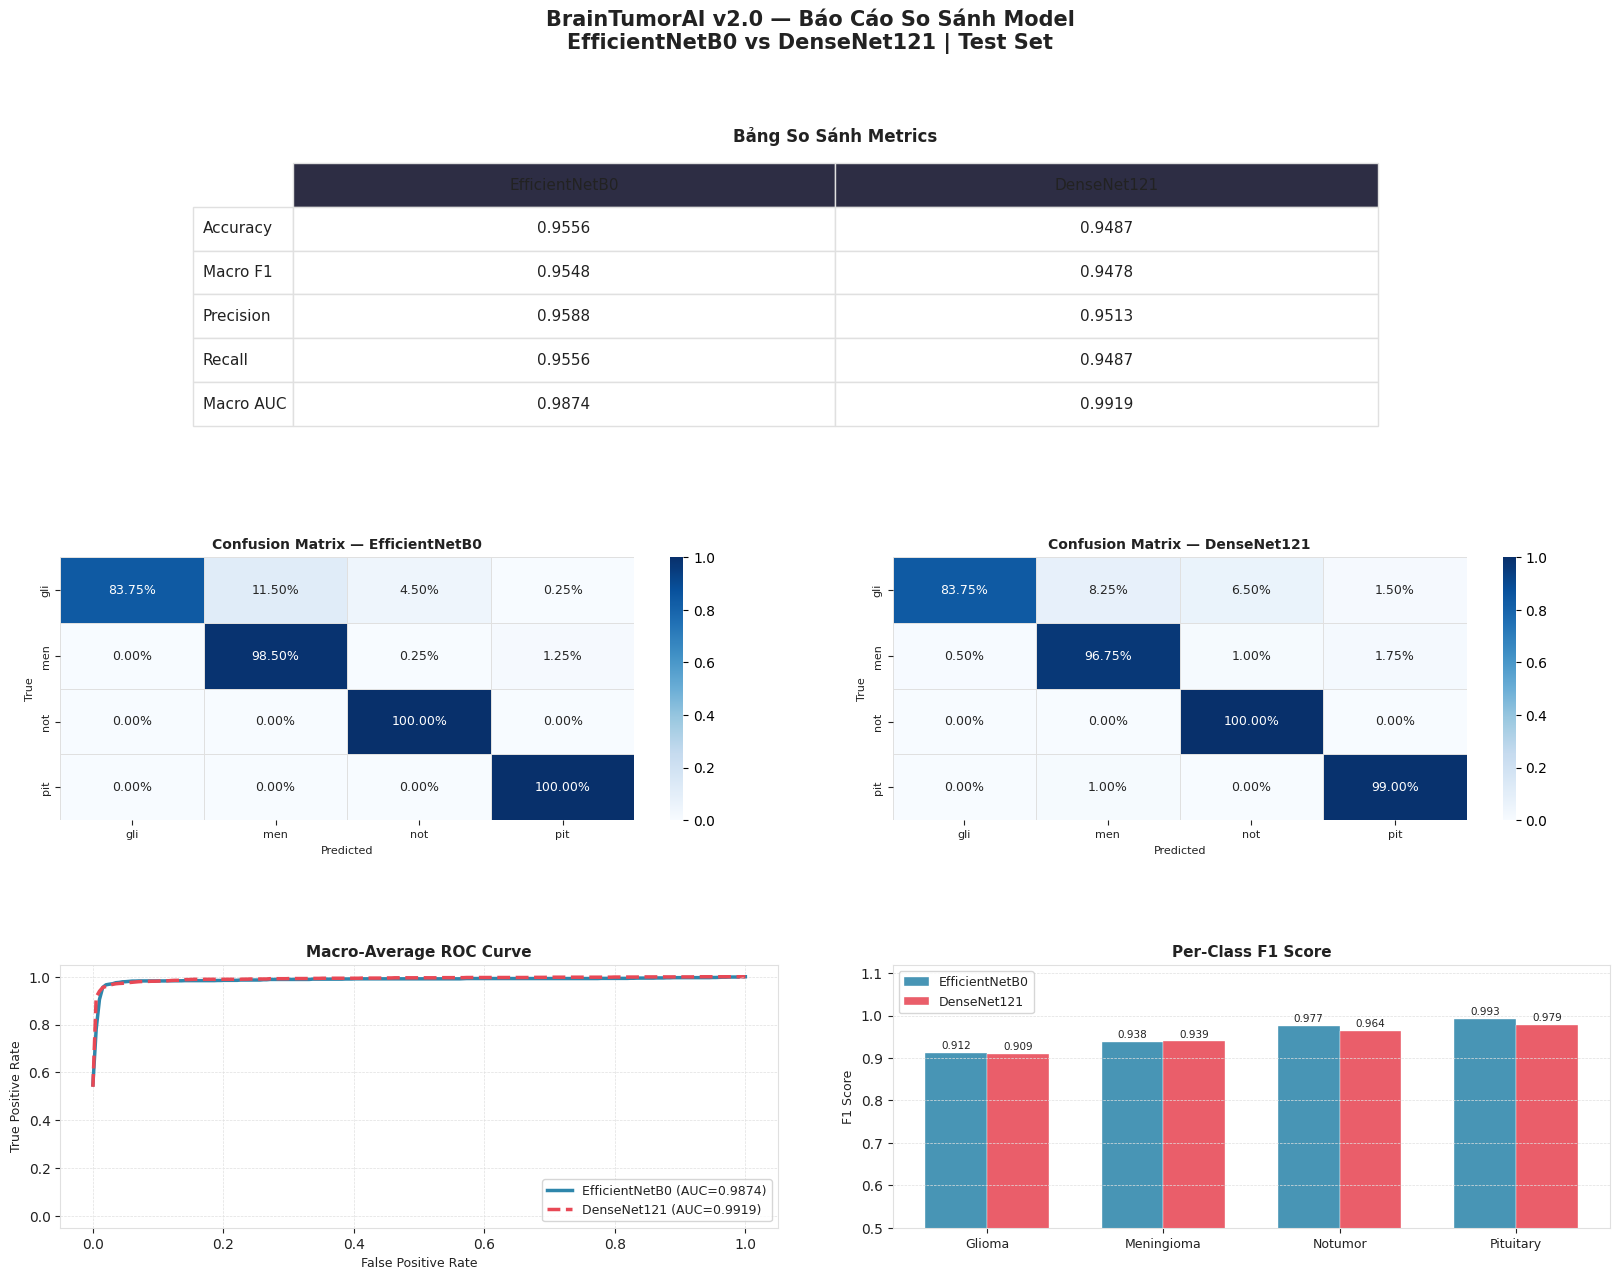

✅ Đã lưu → reports\figures\comparison\dashboard_report.png


In [14]:
if results:
    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor(PALETTE["bg"])
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)

    fig.suptitle(
        "BrainTumorAI v2.0 — Báo Cáo So Sánh Model\nEfficientNetB0 vs DenseNet121 | Test Set",
        color=PALETTE["text"], fontsize=15, fontweight="bold", y=0.98,
    )

    # Row 0: Bảng metrics
    ax_tbl = fig.add_subplot(gs[0, :])
    ax_tbl.set_facecolor(PALETTE["bg"])
    ax_tbl.axis("off")
    tbl_rows = ["Accuracy", "Macro F1", "Precision", "Recall", "Macro AUC"]
    tbl_keys = ["accuracy", "macro_f1", "macro_prec", "macro_rec", "macro_auc"]
    tbl_cols = list(results.keys())
    tbl_data = [
        [f"{res[k]:.4f}" for res in results.values()]
        for k in tbl_keys
    ]
    table = ax_tbl.table(
        cellText=tbl_data, rowLabels=tbl_rows, colLabels=tbl_cols,
        cellLoc="center", loc="center", bbox=[0.15, -0.05, 0.7, 1.0],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    for (r, c), cell in table.get_celld().items():
        bg = "#2D2D44" if r == 0 else PALETTE["bg"]
        cell.set_facecolor(bg)
        cell.set_edgecolor(PALETTE["grid"])
        cell.set_text_props(color=PALETTE["text"])
    ax_tbl.set_title("Bảng So Sánh Metrics", color=PALETTE["text"],
                     fontsize=12, fontweight="bold")

    # Row 1: Confusion matrices
    model_list = list(results.items())
    for col_idx, (model_label, res) in enumerate(model_list):
        ax_cm   = fig.add_subplot(gs[1, col_idx * 2: col_idx * 2 + 2])
        cm      = confusion_matrix(res["y_true"], res["y_pred"])
        cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        sns.heatmap(
            cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=[c[:3] for c in CLASS_NAMES],
            yticklabels=[c[:3] for c in CLASS_NAMES],
            ax=ax_cm, linewidths=0.5, linecolor=PALETTE["grid"],
            annot_kws={"size": 9},
        )
        ax_cm.set_facecolor(PALETTE["bg"])
        ax_cm.tick_params(colors=PALETTE["text"], labelsize=8)
        ax_cm.set_title(
            f"Confusion Matrix — {model_label}",
            color=PALETTE["text"], fontsize=10, fontweight="bold",
        )
        ax_cm.set_xlabel("Predicted", color=PALETTE["text"], fontsize=8)
        ax_cm.set_ylabel("True", color=PALETTE["text"], fontsize=8)

    # Row 2: Macro ROC + Per-class F1
    ax_roc = fig.add_subplot(gs[2, :2])
    ax_roc.set_facecolor(PALETTE["bg"])
    ax_roc.grid(True, color=PALETTE["grid"], linewidth=0.5, linestyle="--")
    ax_roc.spines[:].set_color(PALETTE["grid"])

    for model_label, res in results.items():
        all_fpr  = np.linspace(0, 1, 200)
        mean_tpr = np.zeros_like(all_fpr)
        for cls in CLASS_NAMES:
            fpr, tpr = res["fpr_tpr"][cls]
            mean_tpr += np.interp(all_fpr, fpr, tpr)
        mean_tpr /= NUM_CLASSES
        ls = "-" if model_label == "EfficientNetB0" else "--"
        ax_roc.plot(all_fpr, mean_tpr, linestyle=ls, color=PALETTE[model_label],
                    linewidth=2.5, label=f"{model_label} (AUC={res['macro_auc']:.4f})")

    ax_roc.plot([0, 1], [0, 1], "w--", lw=0.8, alpha=0.4)
    ax_roc.tick_params(colors=PALETTE["text"])
    ax_roc.set_title("Macro-Average ROC Curve", color=PALETTE["text"],
                     fontsize=11, fontweight="bold")
    ax_roc.set_xlabel("False Positive Rate", color=PALETTE["text"], fontsize=9)
    ax_roc.set_ylabel("True Positive Rate", color=PALETTE["text"], fontsize=9)
    ax_roc.legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["text"], fontsize=9)

    ax_f1 = fig.add_subplot(gs[2, 2:])
    ax_f1.set_facecolor(PALETTE["bg"])
    x     = np.arange(NUM_CLASSES)
    width = 0.35
    for i, (model_label, res) in enumerate(model_list):
        offset = (i - 0.5) * width
        bars   = ax_f1.bar(
            x + offset, res["per_class_f1"], width,
            color=PALETTE[model_label], alpha=0.88,
            label=model_label, edgecolor="white", linewidth=0.3,
        )
        for bar, val in zip(bars, res["per_class_f1"]):
            ax_f1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom",
                color=PALETTE["text"], fontsize=7.5,
            )
    ax_f1.set_xticks(x)
    ax_f1.set_xticklabels([c.capitalize() for c in CLASS_NAMES],
                           color=PALETTE["text"], fontsize=9)
    ax_f1.tick_params(colors=PALETTE["text"])
    ax_f1.set_ylim(0.5, 1.12)
    ax_f1.spines[:].set_color(PALETTE["grid"])
    ax_f1.grid(True, axis="y", color=PALETTE["grid"], linewidth=0.5, linestyle="--")
    ax_f1.set_title("Per-Class F1 Score", color=PALETTE["text"],
                    fontsize=11, fontweight="bold")
    ax_f1.set_ylabel("F1 Score", color=PALETTE["text"], fontsize=9)
    ax_f1.legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["text"], fontsize=9)

    out = os.path.join(FIGURES_DIR, "dashboard_report.png")
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print(f"✅ Đã lưu → {os.path.relpath(out, ROOT)}")

### 3.7 — Lưu Evaluation Summary JSON

In [15]:
if results:
    summary = {}
    for model_label, res in results.items():
        summary[model_label] = {
            "accuracy":              round(res["accuracy"],   6),
            "macro_f1":              round(res["macro_f1"],   6),
            "macro_precision":       round(res["macro_prec"], 6),
            "macro_recall":          round(res["macro_rec"],  6),
            "macro_auc":             round(res["macro_auc"],  6),
            "auc_per_class":         {k: round(v, 6) for k, v in res["auc_per_class"].items()},
            "per_class_f1":          {
                CLASS_NAMES[i]: round(float(v), 6)
                for i, v in enumerate(res["per_class_f1"])
            },
            "n_test_samples":        res["n_samples"],
            "inference_time_s":      round(res["elapsed_s"], 2),
            "classification_report": res["report_str"],
        }

    out_json = os.path.join(REPORTS_DIR, "model_comparison_report.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    print(f"✅ Đã lưu JSON → {os.path.relpath(out_json, ROOT)}")

✅ Đã lưu JSON → reports\model_comparison_report.json


---
## Tổng Kết

| File biểu đồ | Nội dung |
|---|---|
| `training_history_styled.png` | Đường cong Loss & Accuracy theo epoch |
| `confusion_matrices_comparison.png` | Ma trận nhầm lẫn 2 model (normalized %) |
| `roc_curves_comparison.png` | ROC curve từng class |
| `metrics_comparison_bar.png` | Bar chart so sánh tổng quan |
| `per_class_f1_comparison.png` | F1 score từng loại u não |
| `dashboard_report.png` | **Dashboard tổng hợp dùng cho báo cáo** |

Tất cả lưu tại: `reports/figures/comparison/`  
JSON report: `reports/model_comparison_report.json`

In [16]:
print("  HOÀN TẤT — TẤT CẢ BIỂU ĐỒ ĐÃ ĐƯỢC TẠO")
print("-" * 65)
print(f"\nThư mục biểu đồ: {os.path.relpath(FIGURES_DIR, ROOT)}")
print(f"Report JSON    : reports/model_comparison_report.json")

  HOÀN TẤT — TẤT CẢ BIỂU ĐỒ ĐÃ ĐƯỢC TẠO
-----------------------------------------------------------------

Thư mục biểu đồ: reports\figures\comparison
Report JSON    : reports/model_comparison_report.json
